In [52]:
import pandas as pd

In [53]:
df = pd.read_csv("t826_crystallizer_pivot.csv")

In [3]:
df.head()

,instrument_tag_ts,826fqr23,826lr04,8826lr05,826lr06,8826trc07,826trc07_deltat,826trc08,826trc08_deltat,826trc09,826trc09_deltat,826xv01,826xv14,826xv15,826xv16,826xv18,alarm
0,2025-08-27 11:01:24.000,'-3.98,6.24,'-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,NaN,NaN,NaN,NaN,NaN,1
1,2025-08-27 11:01:25.000,'-4.01,6.26,'-0.03,1.13,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0
2,2025-08-27 11:01:26.000,'-3.93,6.28,'-0.03,1.13,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0
3,2025-08-27 11:01:27.000,'-4.09,6.29,'-0.03,1.13,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0
4,2025-08-27 11:01:28.000,'-4.14,6.29,'-0.03,1.13,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0


In [4]:
df.columns

Index(['instrument_tag_ts', '826fqr23', '826lr04', '8826lr05', '826lr06',
       '8826trc07', '826trc07_deltat', '826trc08', '826trc08_deltat',
       '826trc09', '826trc09_deltat', '826xv01', '826xv14', '826xv15',
       '826xv16', '826xv18', 'alarm'],
      dtype='object')

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1613548 entries, 0 to 1613547
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   instrument_tag_ts  1613548 non-null  object 
 1   826fqr23           1612533 non-null  object 
 2   826lr04            1612785 non-null  object 
 3   8826lr05           1612773 non-null  object 
 4   826lr06            1609194 non-null  object 
 5   8826trc07          230417 non-null   float64
 6   826trc07_deltat    1612789 non-null  object 
 7   826trc08           230416 non-null   float64
 8   826trc08_deltat    1612783 non-null  object 
 9   826trc09           230415 non-null   float64
 10  826trc09_deltat    1612777 non-null  object 
 11  826xv01            31 non-null       float64
 12  826xv14            17 non-null       float64
 13  826xv15            13 non-null       float64
 14  826xv16            39 non-null       float64
 15  826xv18            29 non-null  

In [6]:
print(df.describe(include='all'))

              instrument_tag_ts 826fqr23  826lr04 8826lr05  826lr06  \
count                   1613548  1612533  1612785  1612773  1609194   
unique                  1613548    12053     9568     6983     5262   
top     2025-08-27 11:01:24.000   '-7.55   '-0.04   '-0.03   '-0.03   
freq                          1     5519   966663   863849  1216057   
mean                        NaN      NaN      NaN      NaN      NaN   
std                         NaN      NaN      NaN      NaN      NaN   
min                         NaN      NaN      NaN      NaN      NaN   
25%                         NaN      NaN      NaN      NaN      NaN   
50%                         NaN      NaN      NaN      NaN      NaN   
75%                         NaN      NaN      NaN      NaN      NaN   
max                         NaN      NaN      NaN      NaN      NaN   

            8826trc07  826trc07_deltat       826trc08  826trc08_deltat  \
count   230417.000000        1612789.0  230416.000000        1612783.0   

In [7]:
print(df.isnull().sum())

instrument_tag_ts          0
826fqr23                1015
826lr04                  763
8826lr05                 775
826lr06                 4354
8826trc07            1383131
826trc07_deltat          759
826trc08             1383132
826trc08_deltat          765
826trc09             1383133
826trc09_deltat          771
826xv01              1613517
826xv14              1613531
826xv15              1613535
826xv16              1613509
826xv18              1613519
alarm                      0
dtype: int64


In [8]:
df_cleaned = df.dropna()

In [9]:
df_cleaned.head()

,instrument_tag_ts,826fqr23,826lr04,8826lr05,826lr06,8826trc07,826trc07_deltat,826trc08,826trc08_deltat,826trc09,826trc09_deltat,826xv01,826xv14,826xv15,826xv16,826xv18,alarm


In [10]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_numeric = df.select_dtypes(include=['float64', 'int64'])

imputer = IterativeImputer(max_iter=10, random_state=0)

df_imputed = imputer.fit_transform(df_numeric)

df[df_numeric.columns] = df_imputed

c:\Users\MohamedNadirHAMOU\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt


In [20]:
obj_cols = df.select_dtypes(include="object").columns
obj_cols = obj_cols.difference(["instrument_tag_ts"])


In [22]:
# Timestamp
df["instrument_tag_ts"] = pd.to_datetime(df["instrument_tag_ts"], errors="coerce")

# Colonnes object -> numérique
obj_cols = df.select_dtypes(include="object").columns
obj_cols = obj_cols.difference(["instrument_tag_ts"])

for col in obj_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [27]:
X = df.drop(columns=["alarm", "instrument_tag_ts"])
y = df["alarm"]


print(y.value_counts(normalize=True))


alarm
0    0.980561
1    0.019439
Name: proportion, dtype: float64


In [28]:
num_features = X.columns

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features)
    ]
)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [30]:
log_reg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

log_reg.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


AUC : 0.651755723330903


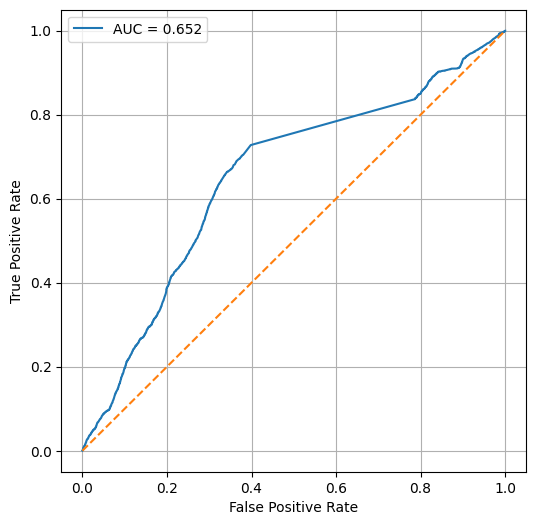

In [31]:
y_proba = log_reg.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("AUC :", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


In [32]:
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


AUC Random Forest : 0.770480916566999


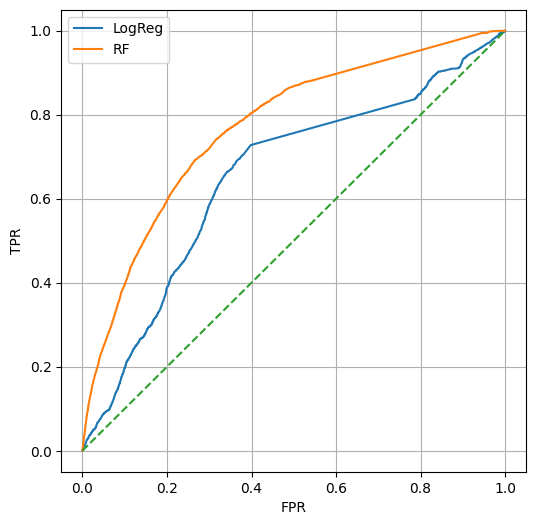

In [33]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
print("AUC Random Forest :", auc_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="LogReg")
plt.plot(fpr_rf, tpr_rf, label="RF")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

In [34]:
threshold = 0.3
y_pred_custom = (y_proba_rf > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.99      0.46      0.63    395546
           1       0.03      0.88      0.06      7841

    accuracy                           0.47    403387
   macro avg       0.51      0.67      0.34    403387
weighted avg       0.98      0.47      0.62    403387



## Équilibrage du dataset

In [35]:
from sklearn.utils import resample

df_train = X_train.copy()
df_train["alarm"] = y_train.values

df_0 = df_train[df_train.alarm == 0]
df_1 = df_train[df_train.alarm == 1]

# Ratio 1:5 (à ajuster)
df_0_down = resample(
    df_0,
    replace=False,
    n_samples=5 * len(df_1),
    random_state=42
)

df_balanced = pd.concat([df_0_down, df_1])

X_train_bal = df_balanced.drop(columns="alarm")
y_train_bal = df_balanced["alarm"]


In [36]:
rf_bal = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=50,
        n_jobs=-1,
        random_state=42
    ))
])

rf_bal.fit(X_train_bal, y_train_bal)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Nouvelle ROC après équilibrage

In [37]:
y_proba_bal = rf_bal.predict_proba(X_test)[:, 1]
auc_bal = roc_auc_score(y_test, y_proba_bal)

print("AUC RF équilibré :", auc_bal)


AUC RF équilibré : 0.7707139768765583


In [39]:
rf_cost = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=14,
        min_samples_leaf=100,
        class_weight={0: 1, 1: 10},
        n_jobs=-1,
        random_state=42
    ))
])

rf_cost.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_proba_bal)
print("PR-AUC :", pr_auc)


PR-AUC : 0.06969693253813034


In [41]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=64,
    max_depth=12,
    learning_rate=0.05,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    preprocessor.fit_transform(X_train),
    y_train
)


[LightGBM] [Info] Number of positive: 23524, number of negative: 1186637
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2057
[LightGBM] [Info] Number of data points in the train set: 1210161, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019439 -> initscore=-3.920857
[LightGBM] [Info] Start training from score -3.920857


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,12
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
sensor_cols = [c for c in X.columns if "trc" in c or "lr" in c]

df_sorted = df.sort_values("instrument_tag_ts")

for col in sensor_cols:
    df_sorted[f"{col}_lag1"] = df_sorted[col].shift(1)
    df_sorted[f"{col}_lag5"] = df_sorted[col].shift(5)


In [43]:
for col in sensor_cols:
    df_sorted[f"{col}_diff"] = df_sorted[col] - df_sorted[f"{col}_lag1"]


In [44]:
for col in sensor_cols:
    df_sorted[f"{col}_roll_mean"] = df_sorted[col].rolling(10).mean()
    df_sorted[f"{col}_roll_std"]  = df_sorted[col].rolling(10).std()


In [45]:
split_date = df_sorted["instrument_tag_ts"].quantile(0.75)

train_df = df_sorted[df_sorted["instrument_tag_ts"] <= split_date]
test_df  = df_sorted[df_sorted["instrument_tag_ts"] > split_date]

X_train = train_df.drop(columns=["alarm", "instrument_tag_ts"])
y_train = train_df["alarm"]

X_test = test_df.drop(columns=["alarm", "instrument_tag_ts"])
y_test = test_df["alarm"]


In [46]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,  # ≈ taux d'alarmes
    random_state=42,
    n_jobs=-1
)

X_train_num = preprocessor.fit_transform(X_train)
iso.fit(X_train_num)

scores = -iso.decision_function(preprocessor.transform(X_test))


In [47]:
auc_iso = roc_auc_score(y_test, scores)
print("AUC IsolationForest :", auc_iso)


AUC IsolationForest : 0.49951325696470006


In [50]:
print("*" * 100)

****************************************************************************************************


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [54]:
print("Shape des données:", df.shape)
print("\nValeurs manquantes:")
print(df.isnull().sum())
print("\nDistribution de la variable cible 'alarm':")
print(df['alarm'].value_counts())
print(f"\nPourcentage de classe positive: {df['alarm'].mean()*100:.2f}%")

Shape des données: (1613548, 17)

Valeurs manquantes:
instrument_tag_ts          0
826fqr23                1015
826lr04                  763
8826lr05                 775
826lr06                 4354
8826trc07            1383131
826trc07_deltat          759
826trc08             1383132
826trc08_deltat          765
826trc09             1383133
826trc09_deltat          771
826xv01              1613517
826xv14              1613531
826xv15              1613535
826xv16              1613509
826xv18              1613519
alarm                      0
dtype: int64

Distribution de la variable cible 'alarm':
alarm
0    1582183
1      31365
Name: count, dtype: int64

Pourcentage de classe positive: 1.94%


In [55]:
df['instrument_tag_ts'] = pd.to_datetime(df['instrument_tag_ts'])

colonnes_a_convertir = ['826fqr23', '826lr04', '8826lr05', '826lr06', 
                        '826trc07_deltat', '826trc08_deltat', '826trc09_deltat']

for col in colonnes_a_convertir:
    if col in df.columns:
        df[col] = df[col].str.replace("'", "").astype(float)

print("Conversion des types terminée")
print(df.dtypes)

Conversion des types terminée
instrument_tag_ts    datetime64[ns]
826fqr23                    float64
826lr04                     float64
8826lr05                    float64
826lr06                     float64
8826trc07                   float64
826trc07_deltat             float64
826trc08                    float64
826trc08_deltat             float64
826trc09                    float64
826trc09_deltat             float64
826xv01                     float64
826xv14                     float64
826xv15                     float64
826xv16                     float64
826xv18                     float64
alarm                         int64
dtype: object


In [56]:
df['hour'] = df['instrument_tag_ts'].dt.hour
df['day_of_week'] = df['instrument_tag_ts'].dt.dayofweek
df['day_of_month'] = df['instrument_tag_ts'].dt.day

df_model = df.drop('instrument_tag_ts', axis=1)

print("Features temporelles créées")
print(df_model.head())

Features temporelles créées
   826fqr23  826lr04  8826lr05  826lr06  8826trc07  826trc07_deltat  826trc08  \
0     -3.98      NaN     -0.03      NaN      25.93              NaN     25.72   
1     -4.01      NaN     -0.03      NaN        NaN              NaN       NaN   
2     -3.93      NaN     -0.03      NaN        NaN              NaN       NaN   
3     -4.09      NaN     -0.03      NaN        NaN              NaN       NaN   
4     -4.14      NaN     -0.03      NaN        NaN              NaN       NaN   

   826trc08_deltat  826trc09  826trc09_deltat  826xv01  826xv14  826xv15  \
0              NaN     25.45              NaN      NaN      NaN      NaN   
1              NaN       NaN              NaN      NaN      NaN      NaN   
2              NaN       NaN              NaN      NaN      NaN      NaN   
3              NaN       NaN              NaN      NaN      NaN      NaN   
4              NaN       NaN              NaN      NaN      NaN      NaN   

   826xv16  826xv18  alarm  

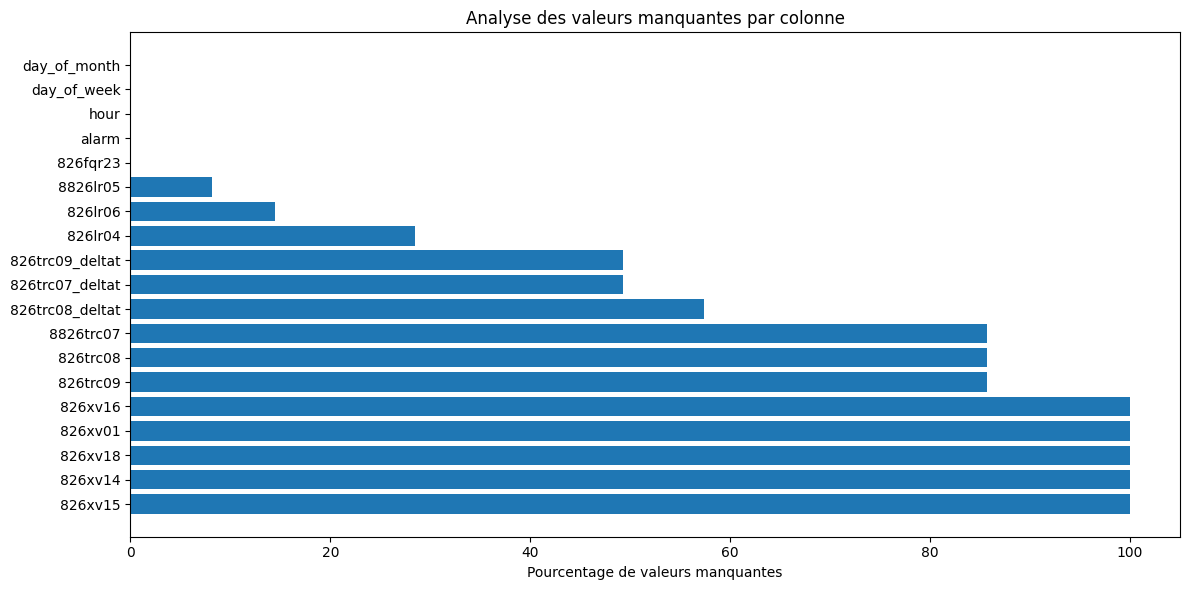

            Colonne  Pourcentage_manquant
12          826xv15             99.999194
11          826xv14             99.998946
14          826xv18             99.998203
10          826xv01             99.998079
13          826xv16             99.997583
8          826trc09             85.719979
6          826trc08             85.719917
4         8826trc07             85.719855
7   826trc08_deltat             57.378336
5   826trc07_deltat             49.259210
9   826trc09_deltat             49.257475
1           826lr04             28.461936
3           826lr06             14.477227
2          8826lr05              8.167219
0          826fqr23              0.062905
15            alarm              0.000000
16             hour              0.000000
17      day_of_week              0.000000
18     day_of_month              0.000000


In [57]:
missing_percent = (df_model.isnull().sum() / len(df_model)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing_percent.index,
    'Pourcentage_manquant': missing_percent.values
}).sort_values('Pourcentage_manquant', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(missing_df['Colonne'], missing_df['Pourcentage_manquant'])
plt.xlabel('Pourcentage de valeurs manquantes')
plt.title('Analyse des valeurs manquantes par colonne')
plt.tight_layout()
plt.show()

print(missing_df)

In [58]:

threshold = 95
colonnes_a_supprimer = missing_df[missing_df['Pourcentage_manquant'] > threshold]['Colonne'].tolist()

print(f"Colonnes à supprimer (>{threshold}% manquantes):")
print(colonnes_a_supprimer)

df_model = df_model.drop(columns=colonnes_a_supprimer)
print(f"\nShape après suppression: {df_model.shape}")

Colonnes à supprimer (>95% manquantes):
['826xv15', '826xv14', '826xv18', '826xv01', '826xv16']

Shape après suppression: (1613548, 14)


In [59]:
X = df_model.drop('alarm', axis=1)
y = df_model['alarm']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nColonnes restantes: {list(X.columns)}")

Features shape: (1613548, 13)
Target shape: (1613548,)

Colonnes restantes: ['826fqr23', '826lr04', '8826lr05', '826lr06', '8826trc07', '826trc07_deltat', '826trc08', '826trc08_deltat', '826trc09', '826trc09_deltat', 'hour', 'day_of_week', 'day_of_month']


In [60]:
# Cellule 8: Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribution train: {y_train.value_counts(normalize=True)}")
print(f"Distribution test: {y_test.value_counts(normalize=True)}")

Train set: (1129483, 13)
Test set: (484065, 13)

Distribution train: alarm
0    0.980562
1    0.019438
Name: proportion, dtype: float64
Distribution test: alarm
0    0.98056
1    0.01944
Name: proportion, dtype: float64


In [61]:
# Cellule 9: Imputation des valeurs manquantes
# Imputation par la médiane pour les features numériques
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns)

print("Imputation terminée")
print(f"Valeurs manquantes restantes (train): {X_train_imputed.isnull().sum().sum()}")
print(f"Valeurs manquantes restantes (test): {X_test_imputed.isnull().sum().sum()}")

Imputation terminée
Valeurs manquantes restantes (train): 0
Valeurs manquantes restantes (test): 0


In [62]:
# Cellule 10: Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Standardisation terminée")
print(f"Moyenne train (première feature): {X_train_scaled[:, 0].mean():.6f}")
print(f"Std train (première feature): {X_train_scaled[:, 0].std():.6f}")

Standardisation terminée
Moyenne train (première feature): 0.000000
Std train (première feature): 1.000000


In [63]:
# Cellule 11: Modèle 1 - Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
lr_auc = auc(lr_fpr, lr_tpr)

print(f"Logistic Regression - AUC: {lr_auc:.4f}")

Logistic Regression - AUC: 0.6424


In [64]:
# Cellule 12: Modèle 2 - Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced',
    max_depth=10,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
rf_auc = auc(rf_fpr, rf_tpr)

print(f"Random Forest - AUC: {rf_auc:.4f}")

Random Forest - AUC: 0.8107


In [65]:
# Cellule 13: Modèle 3 - Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1,
    max_depth=5
)
gb_model.fit(X_train_scaled, y_train)

gb_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_pred_proba)
gb_auc = auc(gb_fpr, gb_tpr)

print(f"Gradient Boosting - AUC: {gb_auc:.4f}")

Gradient Boosting - AUC: 0.8028


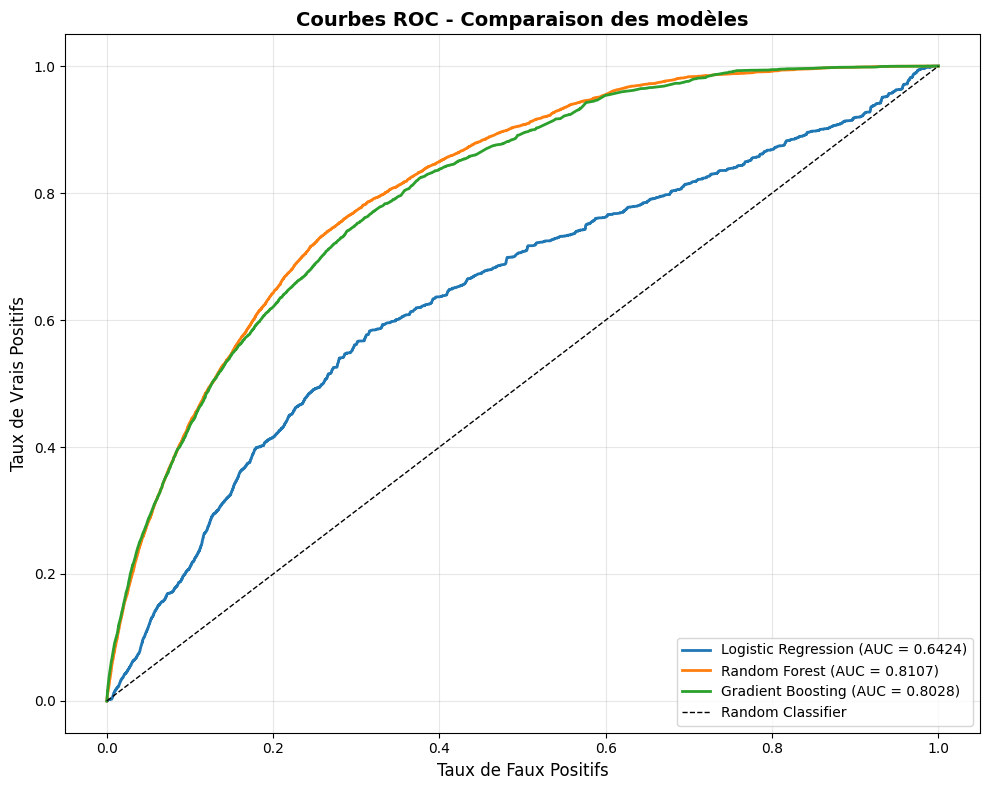

In [66]:
# Cellule 14: Comparaison des courbes ROC
plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2)
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

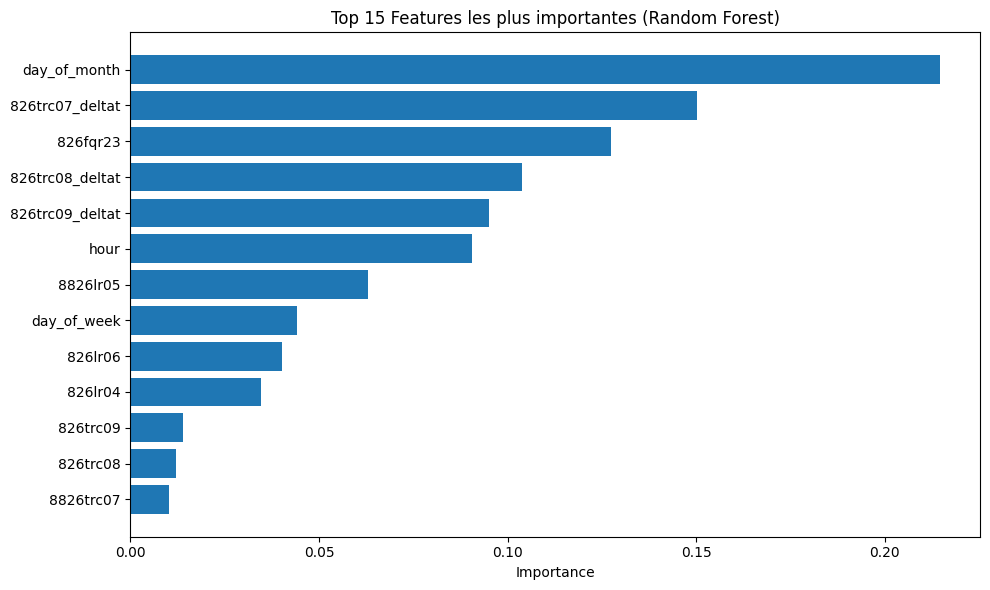

            feature  importance
12     day_of_month    0.214521
5   826trc07_deltat    0.150195
0          826fqr23    0.127479
7   826trc08_deltat    0.103876
9   826trc09_deltat    0.095114
10             hour    0.090481
2          8826lr05    0.062999
11      day_of_week    0.044228
3           826lr06    0.040294
1           826lr04    0.034728


In [67]:
# Cellule 15: Importance des features (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features les plus importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

RAPPORT DE CLASSIFICATION - MEILLEUR MODÈLE
              precision    recall  f1-score   support

           0       0.99      0.70      0.82    474655
           1       0.05      0.77      0.09      9410

    accuracy                           0.70    484065
   macro avg       0.52      0.74      0.46    484065
weighted avg       0.98      0.70      0.81    484065



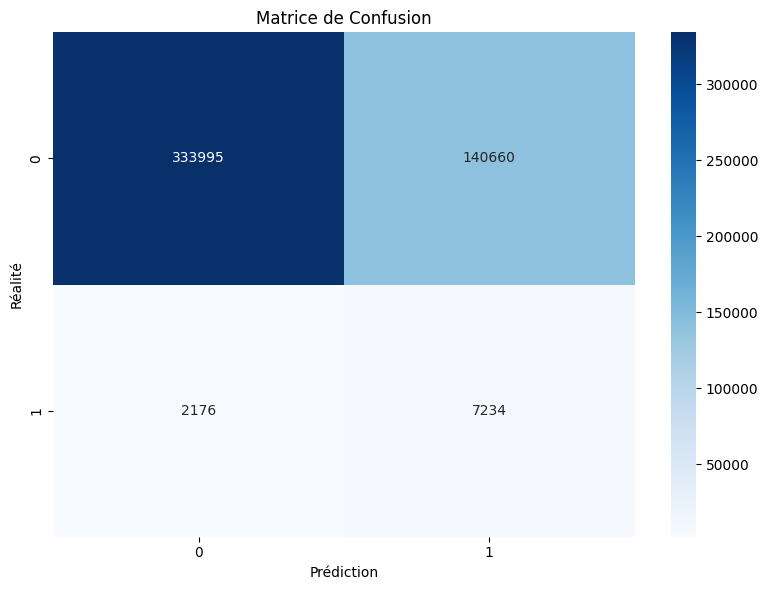

In [68]:
# Cellule 16: Rapport de classification (meilleur modèle)
# Utilisons le meilleur modèle basé sur l'AUC
best_model = rf_model  # ou gb_model selon vos résultats
best_pred = best_model.predict(X_test_scaled)

print("=" * 50)
print("RAPPORT DE CLASSIFICATION - MEILLEUR MODÈLE")
print("=" * 50)
print(classification_report(y_test, best_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

In [69]:
# Cellule 17: Amélioration - Ajustement du seuil
from sklearn.metrics import precision_recall_curve

# Calculer precision-recall pour différents seuils
precision, recall, thresholds = precision_recall_curve(y_test, rf_pred_proba)

# Trouver le meilleur seuil (F1-score maximal)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx] if best_threshold_idx < len(thresholds) else 0.5

print(f"Seuil optimal: {best_threshold:.4f}")
print(f"F1-score maximal: {f1_scores[best_threshold_idx]:.4f}")

# Prédictions avec seuil optimisé
rf_pred_optimized = (rf_pred_proba >= best_threshold).astype(int)

print("\n" + "=" * 50)
print("RAPPORT AVEC SEUIL OPTIMISÉ")
print("=" * 50)
print(classification_report(y_test, rf_pred_optimized))

Seuil optimal: 0.7438
F1-score maximal: 0.1508

RAPPORT AVEC SEUIL OPTIMISÉ
              precision    recall  f1-score   support

           0       0.98      0.96      0.97    474655
           1       0.11      0.25      0.15      9410

    accuracy                           0.94    484065
   macro avg       0.55      0.61      0.56    484065
weighted avg       0.97      0.94      0.96    484065



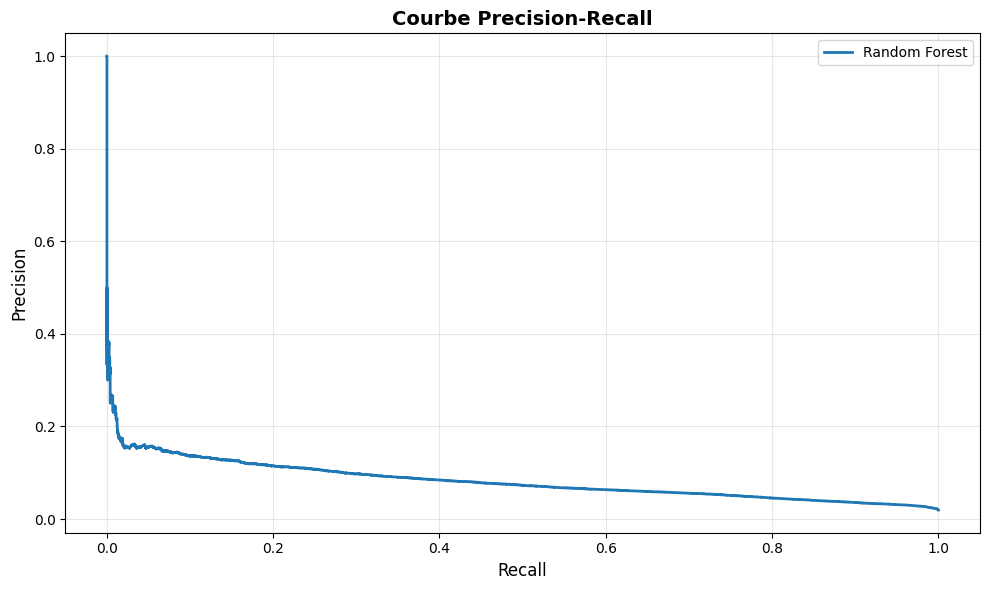

In [70]:
# Cellule 18: Courbe Precision-Recall
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, label='Random Forest')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Cellule 19: Résumé des performances
summary = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'AUC': [lr_auc, rf_auc, gb_auc]
}).sort_values('AUC', ascending=False)

print("\n" + "=" * 50)
print("RÉSUMÉ DES PERFORMANCES")
print("=" * 50)
print(summary.to_string(index=False))
print("\nMeilleur modèle:", summary.iloc[0]['Modèle'])


RÉSUMÉ DES PERFORMANCES
             Modèle      AUC
      Random Forest 0.810680
  Gradient Boosting 0.802789
Logistic Regression 0.642423

Meilleur modèle: Random Forest


In [72]:
# Cellule 1: Analyse du déséquilibre
print("=" * 60)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("=" * 60)
print(f"\nClasse 0 (pas d'alarme): {(y_train == 0).sum():,} échantillons ({(y_train == 0).mean()*100:.2f}%)")
print(f"Classe 1 (alarme): {(y_train == 1).sum():,} échantillons ({(y_train == 1).mean()*100:.2f}%)")
print(f"\nRatio de déséquilibre: 1:{int((y_train == 0).sum() / (y_train == 1).sum())}")

ANALYSE DU DÉSÉQUILIBRE DES CLASSES

Classe 0 (pas d'alarme): 1,107,528 échantillons (98.06%)
Classe 1 (alarme): 21,955 échantillons (1.94%)

Ratio de déséquilibre: 1:50


In [73]:
# Cellule 2: Stratégie 1 - SMOTE (Synthetic Minority Over-sampling)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE pour générer des exemples synthétiques de la classe minoritaire
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Après SMOTE:")
print(f"Classe 0: {(y_train_smote == 0).sum():,} échantillons")
print(f"Classe 1: {(y_train_smote == 1).sum():,} échantillons")
print(f"Nouveau ratio: {(y_train_smote == 1).mean()*100:.2f}% classe positive")

Après SMOTE:
Classe 0: 1,107,528 échantillons
Classe 1: 1,107,528 échantillons
Nouveau ratio: 50.00% classe positive


In [78]:
# Cellule 4: Modèle avec données équilibrées - Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

rf_balanced.fit(X_train_smote, y_train_smote)

rf_bal_pred_proba = rf_balanced.predict_proba(X_test_scaled)[:, 1]
rf_bal_fpr, rf_bal_tpr, _ = roc_curve(y_test, rf_bal_pred_proba)
rf_bal_auc = auc(rf_bal_fpr, rf_bal_tpr)

print(f"Random Forest (équilibré) - AUC: {rf_bal_auc:.4f}")

Random Forest (équilibré) - AUC: 0.8285


In [75]:
# Cellule 3: Stratégie 2 - Combinaison SMOTE + Sous-échantillonnage
# Créer un équilibre à 30-70 au lieu de 50-50 (plus réaliste)
smote_tomek = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),  # Augmenter minorité
    ('under', RandomUnderSampler(sampling_strategy=0.7, random_state=42))  # Réduire majorité
])

X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_scaled, y_train)

print("Après SMOTE + Sous-échantillonnage:")
print(f"Classe 0: {(y_train_balanced == 0).sum():,} échantillons")
print(f"Classe 1: {(y_train_balanced == 1).sum():,} échantillons")
print(f"Nouveau ratio: {(y_train_balanced == 1).mean()*100:.2f}% classe positive")

Après SMOTE + Sous-échantillonnage:
Classe 0: 791,091 échantillons
Classe 1: 553,764 échantillons
Nouveau ratio: 41.18% classe positive


In [76]:
# Cellule 4: Modèle avec données équilibrées - Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

rf_balanced.fit(X_train_balanced, y_train_balanced)

rf_bal_pred_proba = rf_balanced.predict_proba(X_test_scaled)[:, 1]
rf_bal_fpr, rf_bal_tpr, _ = roc_curve(y_test, rf_bal_pred_proba)
rf_bal_auc = auc(rf_bal_fpr, rf_bal_tpr)

print(f"Random Forest (équilibré) - AUC: {rf_bal_auc:.4f}")

Random Forest (équilibré) - AUC: 0.8293


In [77]:
# Cellule 5: Modèle avec données équilibrées - Gradient Boosting
gb_balanced = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_samples_split=10,
    subsample=0.8,
    random_state=42
)

gb_balanced.fit(X_train_balanced, y_train_balanced)

gb_bal_pred_proba = gb_balanced.predict_proba(X_test_scaled)[:, 1]
gb_bal_fpr, gb_bal_tpr, _ = roc_curve(y_test, gb_bal_pred_proba)
gb_bal_auc = auc(gb_bal_fpr, gb_bal_tpr)

print(f"Gradient Boosting (équilibré) - AUC: {gb_bal_auc:.4f}")

Gradient Boosting (équilibré) - AUC: 0.8172


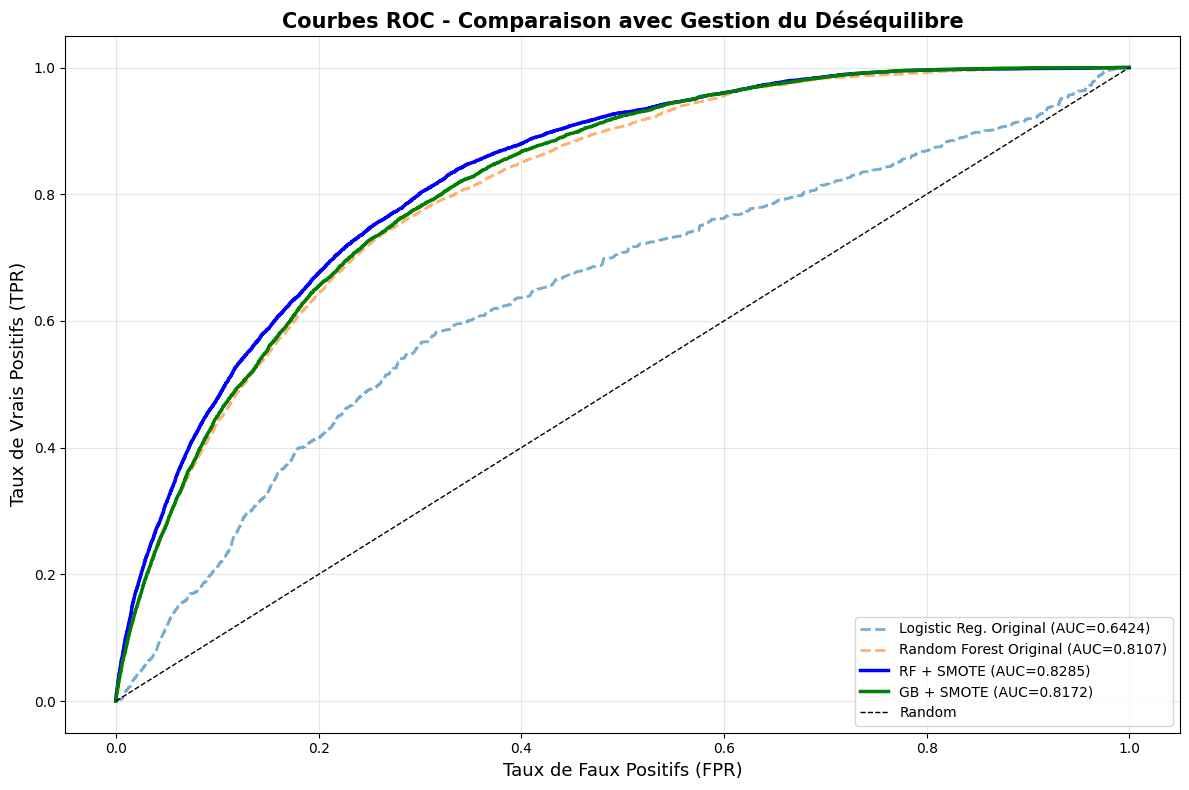

In [79]:
# Cellule 7: Comparaison des courbes ROC - Toutes stratégies
plt.figure(figsize=(12, 8))

# Modèles originaux (déséquilibrés)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Reg. Original (AUC={lr_auc:.4f})', 
         linestyle='--', alpha=0.6, linewidth=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest Original (AUC={rf_auc:.4f})', 
         linestyle='--', alpha=0.6, linewidth=2)

# Modèles avec stratégies d'équilibrage
plt.plot(rf_bal_fpr, rf_bal_tpr, label=f'RF + SMOTE (AUC={rf_bal_auc:.4f})', 
         linewidth=2.5, color='blue')
plt.plot(gb_bal_fpr, gb_bal_tpr, label=f'GB + SMOTE (AUC={gb_bal_auc:.4f})', 
         linewidth=2.5, color='green')

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=13)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=13)
plt.title('Courbes ROC - Comparaison avec Gestion du Déséquilibre', 
          fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

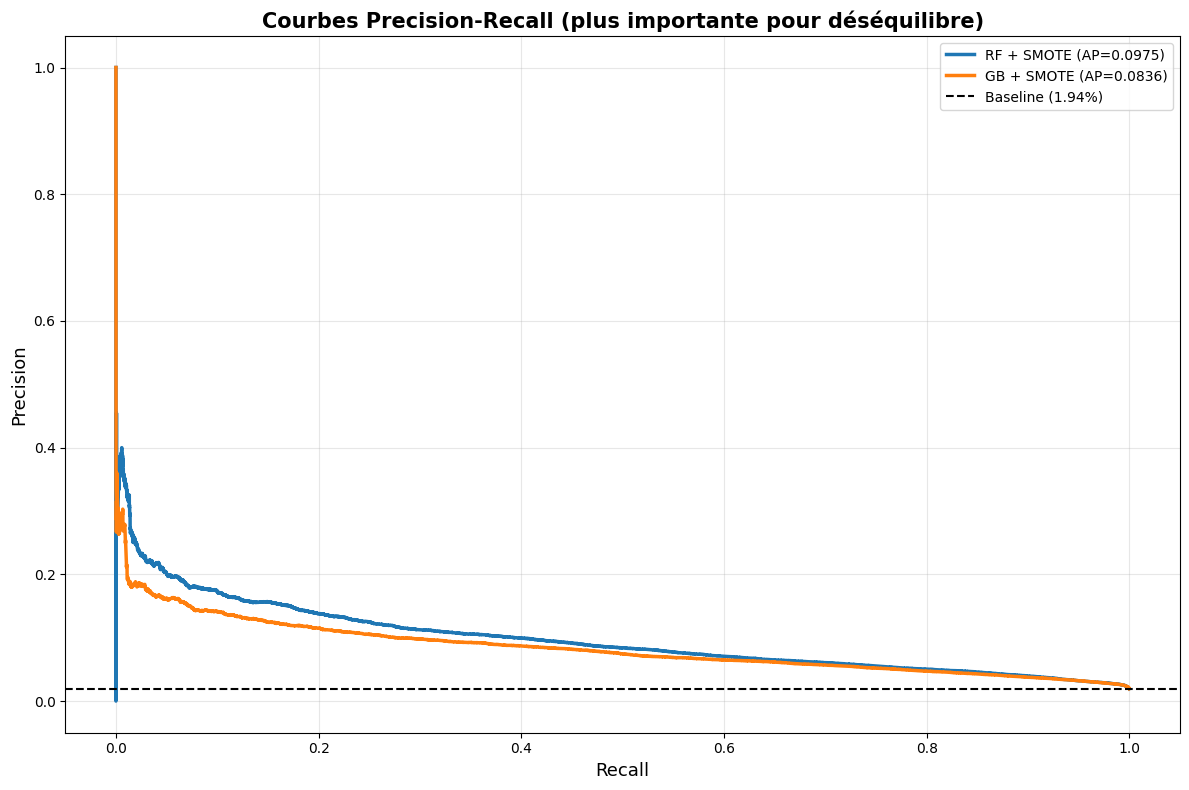

In [80]:
# Cellule 8: Courbe Precision-Recall (plus importante pour classes déséquilibrées)
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculer PR pour chaque modèle
rf_bal_precision, rf_bal_recall, _ = precision_recall_curve(y_test, rf_bal_pred_proba)
gb_bal_precision, gb_bal_recall, _ = precision_recall_curve(y_test, gb_bal_pred_proba)

# Average Precision Score
rf_bal_ap = average_precision_score(y_test, rf_bal_pred_proba)
gb_bal_ap = average_precision_score(y_test, gb_bal_pred_proba)

plt.figure(figsize=(12, 8))
plt.plot(rf_bal_recall, rf_bal_precision, 
         label=f'RF + SMOTE (AP={rf_bal_ap:.4f})', linewidth=2.5)
plt.plot(gb_bal_recall, gb_bal_precision, 
         label=f'GB + SMOTE (AP={gb_bal_ap:.4f})', linewidth=2.5)


# Baseline (proportion de classe positive)
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', 
            label=f'Baseline ({baseline*100:.2f}%)')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Courbes Precision-Recall (plus importante pour déséquilibre)', 
          fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()